In [7]:
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion

import numpy as np
import matplotlib.pyplot as plt
import orcs.process
import orcs.process
import pylab as pl
import orb.utils.io
import numpy as np
from importlib import reload
import pyregion
import orb.utils.graph as graph
from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt

import orcs.process
import pylab as pl
import orb.utils.io
import numpy as np
from importlib import reload
import pyregion
import orb.utils.graph as graph
from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt
import astropy.cosmology as cosmo
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion

from astropy.convolution import convolve, Gaussian2DKernel
from astropy.convolution import interpolate_replace_nans

Smoothing Hbeta

In [8]:
from scipy.ndimage import median_filter, gaussian_filter
flux = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4861.1x1.flux.fits') 
err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4861.1x1.flux-err.fits')

finite = np.isfinite(flux) & np.isfinite(err)

# 2) Reject invalid error values
valid_err = err > 0

# 3) Local median of the flux map
local_med = median_filter(flux, size=3, mode="nearest")

# 4) Robust local residual scale
resid = flux - local_med
resid_finite = resid[np.isfinite(resid)]
med_resid = np.nanmedian(resid_finite)
mad = np.nanmedian(np.abs(resid_finite - med_resid))
sigma = 1.4826 * mad

# 5) Bad-pixel mask
bad = (~finite) | (~valid_err) | (np.abs(resid - med_resid) > 5 * sigma)

# 6) Replace only bad pixels with local median
repaired = flux.copy()
repaired[bad] = local_med[bad]

# 7) Very light smoothing
final = gaussian_filter(repaired, sigma=0.5)

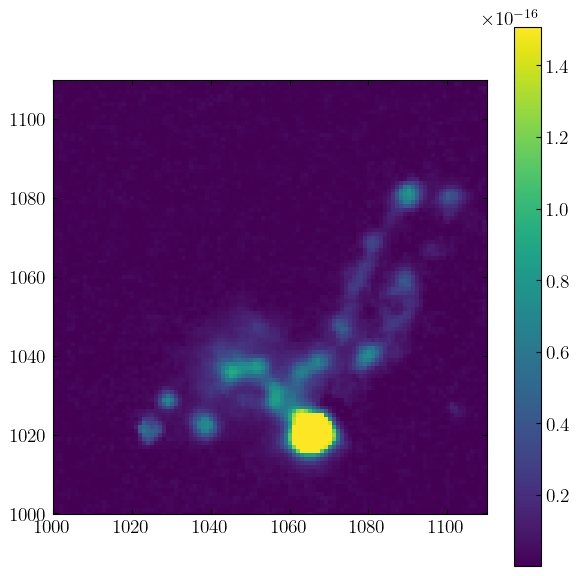

In [9]:
graph.imshow(final)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()

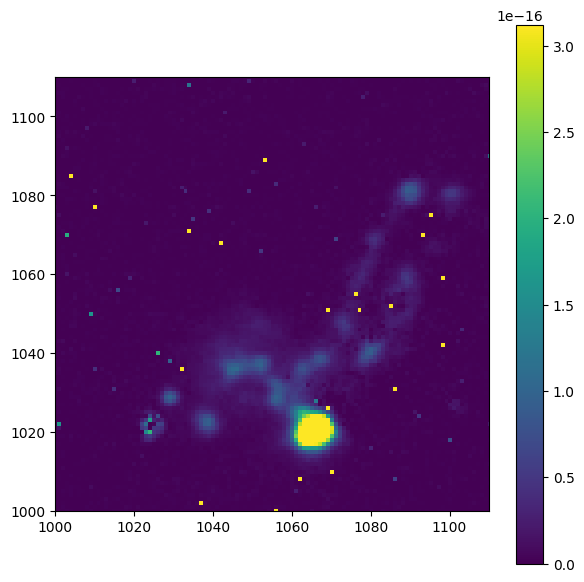

In [4]:
flux = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4861.1x1.flux.fits') 
graph.imshow(flux)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()

Smoothing OIII

In [22]:
flux1 = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4959.1x1.flux.fits')
err1 = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4959.1x1.flux-err.fits')

finite = np.isfinite(flux1) & np.isfinite(err1)

# 2) Reject invalid error values
valid_err = err1 > 0

# 3) Local median of the flux map
local_med = median_filter(flux1, size=3, mode="nearest")

# 4) Robust local residual scale
resid = flux1 - local_med
resid_finite = resid[np.isfinite(resid)]
med_resid = np.nanmedian(resid_finite)
mad = np.nanmedian(np.abs(resid_finite - med_resid))
sigma = 1.4826 * mad

# 5) Bad-pixel mask
bad = (~finite) | (~valid_err) | (np.abs(resid - med_resid) > 5 * sigma)

# 6) Replace only bad pixels with local median
repaired = flux.copy()
repaired[bad] = local_med[bad]

# 7) Optional very light smoothing
final1 = gaussian_filter(repaired, sigma=1.5)

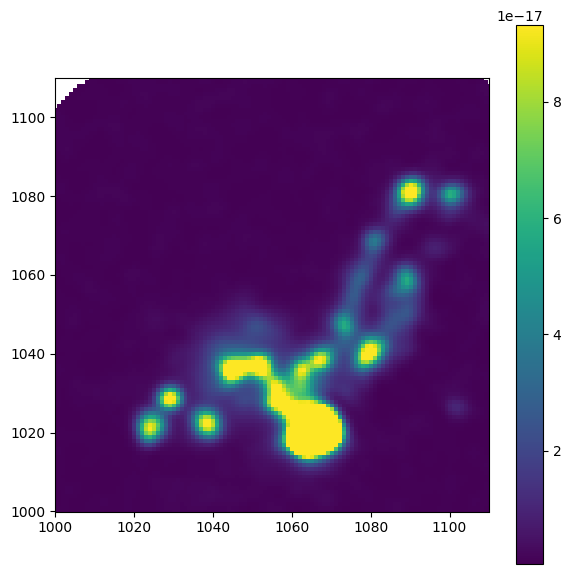

In [23]:
graph.imshow(final1)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()

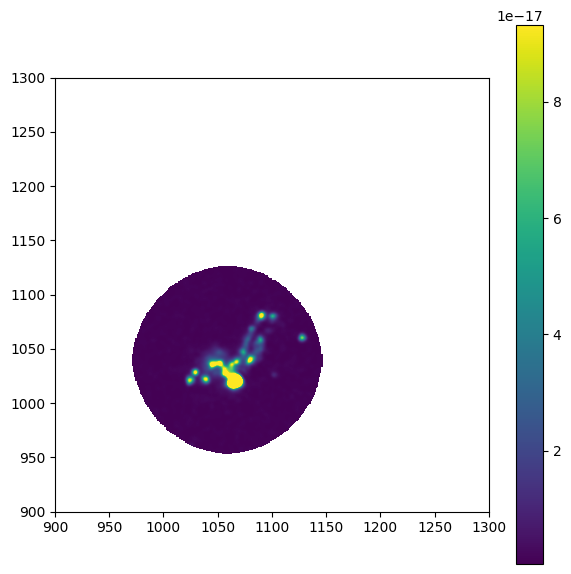

In [29]:
graph.imshow(final1)
#pl.xlim(500, 600)
#pl.ylim(500, 600)
#pl.xlim(250, 500)
#pl.ylim(250, 500)
pl.xlim(900,1300)
pl.ylim(900,1300)
pl.colorbar()

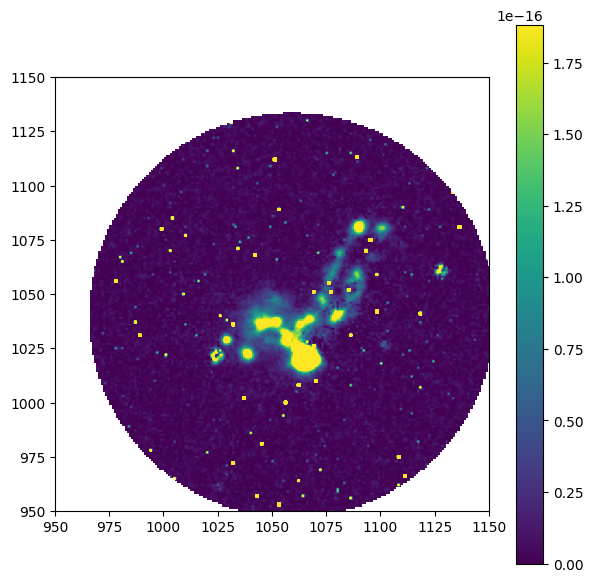

In [32]:
flux1 = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4959.1x1.flux.fits') 
graph.imshow(flux1)
#pl.xlim(1000, 1110)
#pl.ylim(1000, 1110)
pl.xlim(950,1150)
pl.ylim(950,1150)
pl.colorbar()

In [10]:
# Calzetti et al. (2000) attenuation curve

Rv = 4.05

# Wavelengths in microns
lambda_Halpha = 6563 / 10000   
lambda_Hbeta  = 4861 / 10000 


# Hbeta: 0.12 < lambda < 0.63 μm
k_hbeta = (2.659 *(-2.156 + (1.509 / lambda_Hbeta) - (0.198 / (lambda_Hbeta**2)) + (0.011 / (lambda_Hbeta**3)))+ Rv)


# Halpha: 0.63 < lambda < 2.20 μm
k_halpha = (2.659 *(-1.857 + (1.040 / lambda_Halpha)) + Rv)


print("k(Halpha) =", k_halpha)
print("k(Hbeta)  =", k_hbeta)

k(Halpha) = 3.325797871552644
k(Hbeta)  = 4.598085137101848


In [ ]:
map_ha[map_ha<0] = np.nan
ha_line_snr = map_ha / map_ha_err
map_ha[ha_line_snr<=3] = np.nan


map_hb[map_hb<0] = np.nan
hb_line_snr = map_hb / map_hb_err
map_hb[hb_line_snr<=3] = np.nan

unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 419)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False
unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_5061/2765411670.py:49: RuntimeWarning: invalid value encountered in divide
  hb_line_snr = map_hb / map_hb_err

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_5061/2765411670.py:53: RuntimeWarning: invalid value encountered in divide
  hb_line_snr = map_hb / map_hb_err

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_5061/2765411670.py:69: RuntimeWarning: invalid value encountered in divide
  balmer = map_ha / map_hb



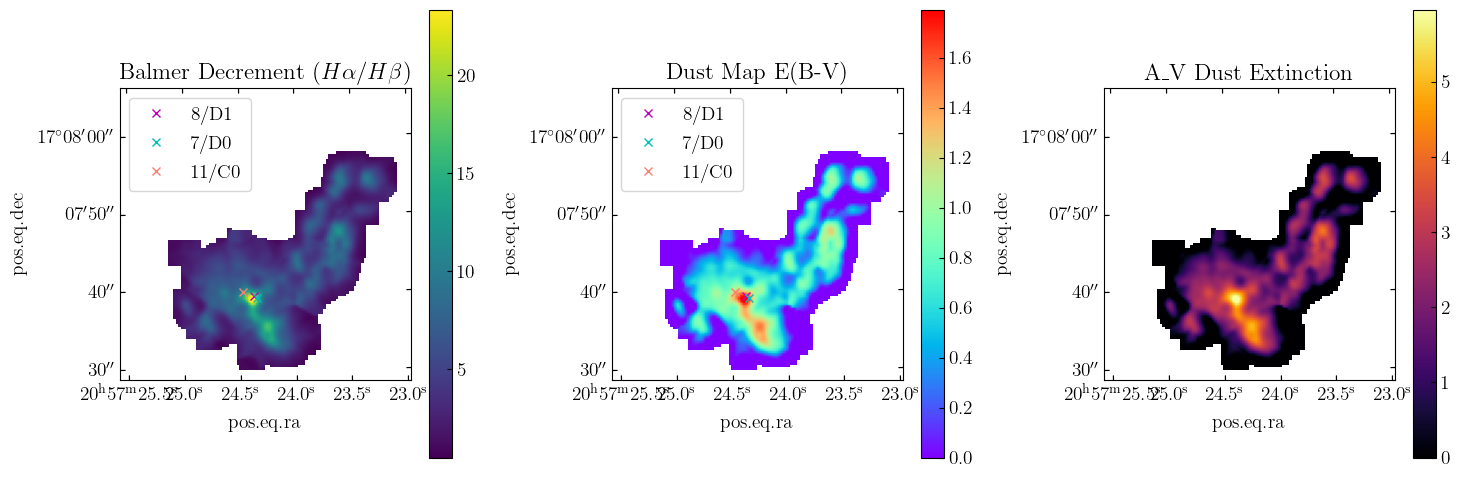

In [17]:
from astropy.io import fits
import numpy as np
import astropy.io.fits as fits
from reproject import reproject_interp
import orb
import orb.utils.graph as graph
import matplotlib.pyplot as plt
from orcs.process import SpectralCube
from astropy.coordinates import SkyCoord
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18
from scipy.ndimage import generic_filter
from astropy.convolution import convolve, Gaussian2DKernel

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
# Recommended for any plot for a science publication.
# Some paper submision systems (e.g. MNRAS) requires next lines to be done for
# your pictures.
# Read more about font types: https://en.wikipedia.org/wiki/PostScript_fonts
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['pdf.fonttype'] = 42
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight']= 'normal'

# to be changed depending on where you save IIZw96 data
data_path = '/Users/leianydeoleo/Desktop/IIZw96/'

cube_SN3 = SpectralCube(data_path + 'SN3.hdf5')

map_ha = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits')
map_ha_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits')
ha_line_snr = map_ha / map_ha_err
#valid_mask = (ha_line_snr > 3) & np.isfinite(map_ha)
#map_ha[~valid_mask] = np.nan
map_ha[map_ha<0] = np.nan
ha_line_snr = map_ha / map_ha_err
map_ha[ha_line_snr<=3.6] = np.nan




map_hb =  flux
map_hb_err = err
hb_line_snr = map_hb / map_hb_err
#valid_mask_hb = (hb_line_snr > 3) & np.isfinite(map_hb)
#map_hb[~valid_mask_hb] = np.nan
map_hb[map_hb<0] = np.nan
hb_line_snr = map_hb / map_hb_err
map_hb[hb_line_snr<=3.6] = np.nan

kernel = Gaussian2DKernel(x_stddev=1.2)

map_ha = convolve(map_ha, kernel, nan_treatment='interpolate', preserve_nan=False)
map_hb = convolve(map_hb, kernel, nan_treatment='interpolate', preserve_nan=False)


position_ID7  = SkyCoord(314.351423, 17.127521, unit='deg')
position_ID8  = SkyCoord(314.351552, 17.127566, unit='deg')
position_ID11 = SkyCoord(314.351972, 17.127732, unit='deg')

def compute_dust_maps():

    # Balmer decrement
    balmer = map_ha / map_hb
    #balmer[balmer <= 0] = np.nan

    intrinsic = 2.86

    # Color excess
    kHa = k_halpha
    kHb = k_hbeta

    EBV = (2.5/(kHb - kHa)) * np.log10(balmer / intrinsic)

    EBV[EBV < 0] = 0

    # Extinction maps
    #Av = Rv * EBV
    Aha = kHa * EBV

    # --------------------------
    # Plot maps
    # --------------------------
    fig = plt.figure(figsize=(15,5))

    ax1 = fig.add_subplot(131, projection=cube_SN3.get_wcs())
    im1 = ax1.imshow(balmer.T, origin='lower',
                     cmap='viridis',
                     vmin=np.nanpercentile(balmer,0),
                     vmax=np.nanpercentile(balmer,99.9))
    # Region ID8/D1
    ax1.plot_coord(position_ID8, "x", c='m', label='8/D1')
    # Region ID7/D0
    ax1.plot_coord(position_ID7, "x", c='c', label='7/D0')
    # Region ID11/C0
    ax1.plot_coord(position_ID11, "x", c='salmon', label='11/C0')
    ax1.legend(loc='upper left')
    ax1.set_title(r"Balmer Decrement ($H\alpha/H\beta$)")
    ax1.set_xlim(1000,1115)
    ax1.set_ylim(1000,1115)
    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_balmer.pdf")
    plt.colorbar(im1, ax=ax1)

    ax2 = fig.add_subplot(132, projection=cube_SN3.get_wcs())
    im2 = ax2.imshow(EBV.T, origin='lower',
        cmap='rainbow',
        vmin=np.nanpercentile(EBV,0), vmax=np.nanpercentile(EBV,99.9)
)
    # Region ID8/D1
    ax2.plot_coord(position_ID8, "x", c='m', label='8/D1')
    # Region ID7/D0
    ax2.plot_coord(position_ID7, "x", c='c', label='7/D0')
    # Region ID11/C0
    ax2.plot_coord(position_ID11, "x", c='salmon', label='11/C0')
    ax2.legend(loc='upper left')
    ax2.set_title("Dust Map E(B-V)")
    ax2.set_xlim(1000,1115)
    ax2.set_ylim(1000,1115)
    plt.colorbar(im2, ax=ax2)

    ax3 = fig.add_subplot(133, projection=cube_SN3.get_wcs())
    im3 = ax3.imshow(Aha.T, origin='lower',
                     cmap='inferno',
                     vmin=np.nanpercentile(Aha,0),
                     vmax=np.nanpercentile(Aha,99.9))
    ax3.set_title("A_V Dust Extinction")
    ax3.set_xlim(1000,1115)
    ax3.set_ylim(1000,1115)
    plt.colorbar(im3, ax=ax3)
    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_av.pdf")

    
    plt.tight_layout()
    plt.show()

    return EBV, Aha, balmer 

EBV, Aha, balmer = compute_dust_maps()

(1000.0, 1110.0)

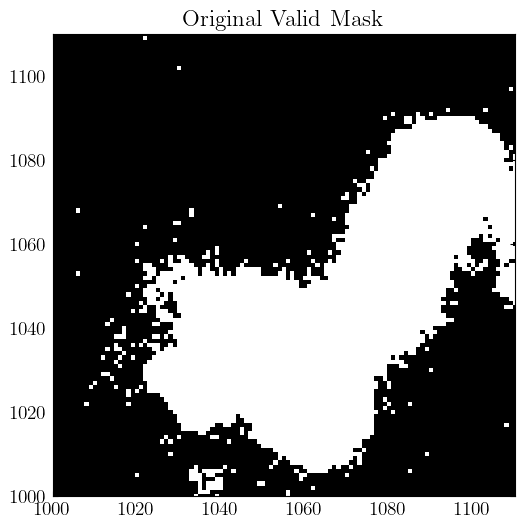

In [15]:
plt.figure(figsize=(6,6))
plt.imshow(valid_mask.T, origin='lower', cmap='gray')
plt.title("Original Valid Mask")
plt.xlim(1000, 1110)
plt.ylim(1000, 1110)

(1000.0, 1110.0)

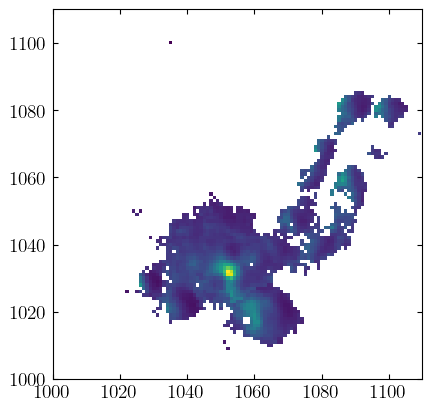

In [13]:
map_ha = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits')
map_hb =  final
balmer = map_ha / map_hb

plt.imshow(balmer.T, origin='lower')
plt.xlim(1000, 1110)
plt.ylim(1000, 1110)

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_32067/3089137512.py:128: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()



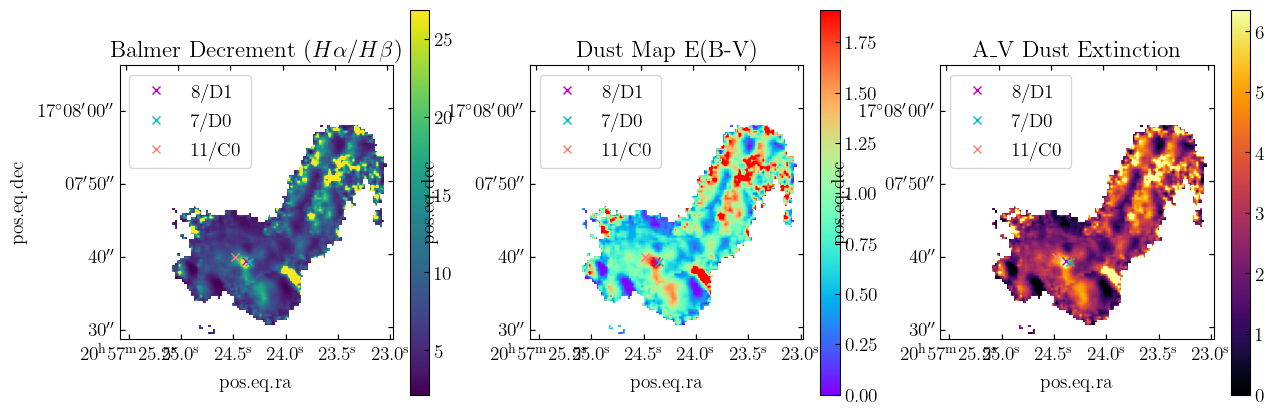

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_32067/431100619.py:77: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()



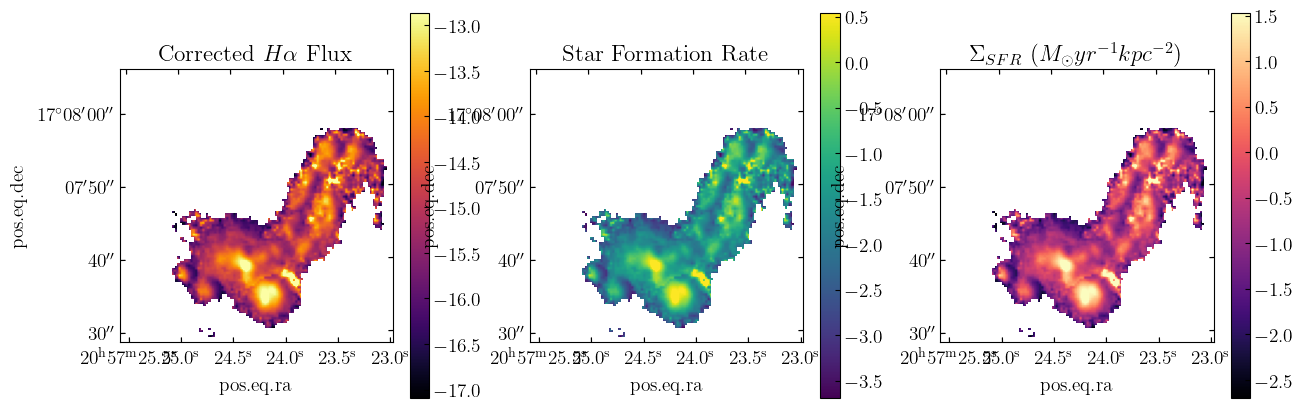

In [23]:
import numpy as np
from astropy.io import fits
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import matplotlib.pyplot as plt
from reproject import reproject_interp
from astropy.wcs import WCS

def compute_sfr_maps():


    # Dust correction
    EBV, Av, Aha = compute_dust_maps()

    # Correct Hα flux for extinction
    ha_corr = map_ha * 10**(0.4 * Aha)
    ha_corr[ha_corr <= 0] = np.nan

    # Flux / Luminosity
    cosmo = Planck18
    redshift = 0.036  # IIZw96
    DL = cosmo.luminosity_distance(redshift).to(u.cm).value


    Lha = 4 * np.pi * (DL**2) * ha_corr

 
    # Luminosity / SFR
    # Kennicutt(1998) relation
    SFR = 7.9e-42 * Lha
    SFR[SFR <= 0] = np.nan

  
    # SFR Surface Density
    pixel_size_kpc =0.32
    pixel_area_kpc2 = pixel_size_kpc**2

    Sigma_SFR = SFR / pixel_area_kpc2

    
    # Plot maps
    fig = plt.figure(figsize=(15,5))

    # Hα corrected flux
    ax1 = fig.add_subplot(131, projection=cube_SN3.get_wcs())
    im1 = ax1.imshow(np.log10(ha_corr.T), origin='lower',
                     cmap='inferno',
                     vmin=np.nanpercentile(np.log10(ha_corr),1),
                     vmax=np.nanpercentile(np.log10(ha_corr),98))
    ax1.set_title(r"Corrected $H\alpha$ Flux")
    ax1.set_xlim(1000,1115)
    ax1.set_ylim(1000,1115)
    plt.colorbar(im1, ax=ax1)

    # SFR map
    ax2 = fig.add_subplot(132, projection=cube_SN3.get_wcs())
    im2 = ax2.imshow(np.log10(SFR.T), origin='lower',
                     cmap='viridis',
                     vmin=np.nanpercentile(np.log10(SFR),0),
                     vmax=np.nanpercentile(np.log10(SFR),95))
    ax2.set_title("Star Formation Rate")
    ax2.set_xlim(1000,1115)
    ax2.set_ylim(1000,1115)
    plt.colorbar(im2, ax=ax2)

    # SFR surface density
    ax3 = fig.add_subplot(133, projection=cube_SN3.get_wcs())
    im3 = ax3.imshow(np.log10(Sigma_SFR.T), origin='lower',
                     cmap='magma',
                     vmin=np.nanpercentile(np.log10(Sigma_SFR),1),
                     vmax=np.nanpercentile(np.log10(Sigma_SFR),98))
    ax3.set_title(r"$\Sigma_{SFR}$ ($M_\odot yr^{-1} kpc^{-2}$)")
    ax3.set_xlim(1000,1115)
    ax3.set_ylim(1000,1115)
    plt.colorbar(im3, ax=ax3)

    plt.tight_layout()
    plt.show()

    return SFR, Sigma_SFR

SFR, Sigma_SFR = compute_sfr_maps()

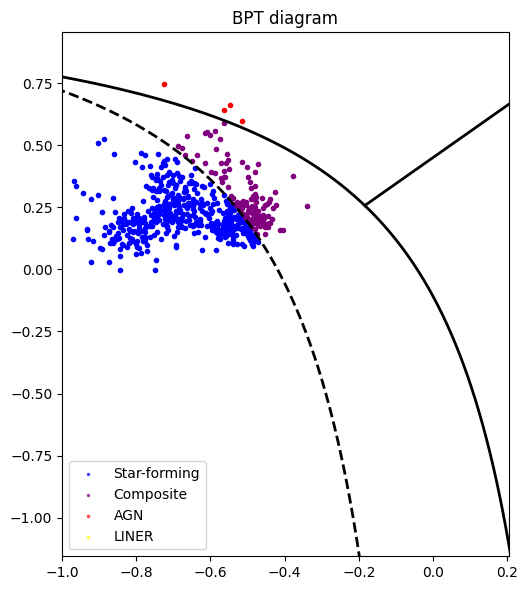

In [19]:
from astropy.io import fits
import numpy as np
import astropy.io.fits as fits
import orb
import orb.utils.graph as graph
import matplotlib.pyplot as plt
from orcs.process import SpectralCube
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.wcs.utils import skycoord_to_pixel
from astropy.wcs.utils import skycoord_to_pixel

# use the header/WCS from one of your FITS maps
   # or the header from map_ha/map_nii/etc.
sitelle_file = (
    "/Users/leianydeoleo/IIZw96_SN3/MAPS/"
    "IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits"
)
sitelle_hdul = fits.open(
    sitelle_file
)

sitelle_flux = (
    sitelle_hdul[0]
    .data
    .astype(float)
)

sitelle_header = (
    sitelle_hdul[0]
    .header
)

wcs = WCS(
    sitelle_header
)

xpix, ypix = skycoord_to_pixel(position_ID8, wcs)
xpix = int(np.round(xpix))
ypix = int(np.round(ypix))
ha = map_ha[ypix, xpix]
hb = map_hb[ypix, xpix]
nii = map_nii[ypix, xpix]
oiii = map_oiii[ypix, xpix]

x_bpt = np.log10(nii / ha)
y_bpt = np.log10(oiii / hb)

map_ha = orb.utils.io.read_fits('/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits')
map_ha_err = orb.utils.io.read_fits('/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits')
map_ha[map_ha<0] = np.nan
ha_line_snr = map_ha / map_ha_err
map_ha[ha_line_snr<=3] = np.nan

map_hb = final
map_hb_err = err
map_hb[map_hb<0] = np.nan
hb_line_snr = map_hb / map_hb_err
map_hb[ha_line_snr<=3] = np.nan


map_nii = orb.utils.io.read_fits('/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.flux.fits')
map_nii_err = orb.utils.io.read_fits('/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.flux-err.fits')
map_nii[map_nii<0] = np.nan
nii_line_snr = map_nii / map_nii_err
map_nii[nii_line_snr<=3] = np.nan

map_oiii = final1
map_oiii_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/IIZw96_SN2.LineMaps.map.4959.1x1.flux-err.fits')
map_oiii[map_oiii<0] = np.nan
oiii_line_snr = map_oiii / map_oiii_err
map_oiii[oiii_line_snr<=3] = np.nan



position_ID7  = SkyCoord(314.351423, 17.127521, unit='deg')
position_ID8  = SkyCoord(314.351552, 17.127566, unit='deg')
position_ID11 = SkyCoord(314.351972, 17.127732, unit='deg')

def classify_first_bpt(oiii_h_beta_ratio, nii_h_alpha_ratio):
        r"""
        Function for classification with BPT diagrams following
         Kewley et al. 2006 doi:10.1111/j.1365-2966.2006.10859.x using equation in Sect. 3.1
         and Schawinski et al. 2007 doi:10.1111/j.1365-2966.2007.12487.x Using equation 1 in Sect. 2.5.1
        :param oiii_h_beta_ratio: log-value of emission line ratio [OIII]5008 / H$\beta$4863
        :type oiii_h_beta_ratio: array-like
        :param nii_h_alpha_ratio: log-value of emission line ratio [NII]6550 / H$\alpha$6565
        :type nii_h_alpha_ratio: array-like
        :return variable specifying the BPT classification
        :rtype: str
        """

        if oiii_h_beta_ratio.ndim > 1:
            classification = np.zeros(oiii_h_beta_ratio.shape, dtype='S6')
        else:
            classification = np.zeros(len(oiii_h_beta_ratio), dtype='S6')

        # sf
        # eq. (1) (Kewley et al. 2006)
        mask_sf = (oiii_h_beta_ratio < 0.61 / (nii_h_alpha_ratio - 0.05) + 1.3) & (nii_h_alpha_ratio < - 0.1)
        classification[mask_sf] = 'sf'

        # composite
        # eq. (4) and (5) (Kewley et al. 2006)
        mask_comp = (((oiii_h_beta_ratio > (0.61 / (nii_h_alpha_ratio - 0.05) + 1.3)) |
                      ((nii_h_alpha_ratio > - 0.1) & (nii_h_alpha_ratio < 0.4))) &
                     (oiii_h_beta_ratio < (0.61 / (nii_h_alpha_ratio - 0.47) + 1.19)))
        classification[mask_comp] = 'comp'

        # agn
        # eq. (6) (Kewley et al. 2006) with limit of nii_h_alpha_ratio < - 1.2825 and eq. (1) (Schawinski et al. 2007)
        mask_agn = (((oiii_h_beta_ratio > (0.61 / (nii_h_alpha_ratio - 0.05) + 1.3)) & (nii_h_alpha_ratio < - 1.2825)) |
                    ((oiii_h_beta_ratio > 0.61 / (nii_h_alpha_ratio - 0.47) + 1.19) & (nii_h_alpha_ratio > - 1.2825)) |
                    ((oiii_h_beta_ratio > 1.05 * nii_h_alpha_ratio + 0.45) & (nii_h_alpha_ratio > - 0.05)))
        classification[mask_agn] = 'agn'

        # liner
        # eq. (11) (Kewley et al. 2006) and eq. (1) (Schawinski et al. 2007)
        mask_liner = (((oiii_h_beta_ratio > 0.61 / (nii_h_alpha_ratio - 0.47) + 1.19) &
                       (oiii_h_beta_ratio < 1.05 * nii_h_alpha_ratio + 0.45)) |
                      ((nii_h_alpha_ratio > 0.45) & (oiii_h_beta_ratio < 1.05 * nii_h_alpha_ratio + 0.45)))
        classification[mask_liner] = 'liner'

        return classification

def save_first_BPT_classification():
    nii_ha_ratio_map = map_nii / map_ha
    oiii_hb_ratio_map = map_oiii / map_hb

    log_nii_ha_map = np.log10( nii_ha_ratio_map )
    log_oiii_hb_map = np.log10( oiii_hb_ratio_map )

    # classification_first_bpt = np.zeros(map_ha.shape, dtype='S20')
    classification_first_bpt = classify_first_bpt(log_oiii_hb_map, log_nii_ha_map )
    # for i in range(hdr['NAXIS2']):
    #     for j in range(hdr['NAXIS1']):
    #         classification_first_bpt[i,j] = classify_first_bpt(log_oiii_hb_map[i,j], log_nii_ha_map [i,j])
    np.save('./classify_first_BPT_ID8_3arcsec.npy', classification_first_bpt)


def plot_BPT_diagram_2d_map_and_scatter_plot():
    nii_ha_ratio_map = map_nii / map_ha
    oiii_hb_ratio_map = map_oiii / map_hb

    log_nii_ha_map = np.log10( nii_ha_ratio_map )
    log_oiii_hb_map = np.log10( oiii_hb_ratio_map )



    fig = plt.figure(figsize=(10,6))



    ax = fig.add_subplot(122)
    ax.scatter(x_bpt, y_bpt, marker='x', s=120, color='black')
    ax.annotate('ID8', (x_bpt, y_bpt), xytext=(6, 6), textcoords='offset points', color='m')

    ax.set_title(r'BPT diagram')
    tt_1 = np.arange(0.01, 1.0, 0.001)
    ax.plot(np.log10(tt_1), 0.61 / (np.log10(tt_1) - 0.05) + 1.3, 'k--', linewidth=2)

    tt_2 = np.arange(0.0521, 2.0, 0.01)
    ax.plot(np.log10(tt_2), 0.61 / (np.log10(tt_2) - 0.47) + 1.19, 'k-', linewidth=2)

    tt_3 = np.arange(0.655, 9.0, 0.01)
    ax.plot(np.log10(tt_3), 1.05 * np.log10(tt_3) + 0.45, 'k-', linewidth=2)

    ax.scatter(log_nii_ha_map[class_first_bpt==1.5], log_oiii_hb_map[class_first_bpt==1.5], marker='.', c='b')
    ax.scatter(log_nii_ha_map[class_first_bpt==2.5], log_oiii_hb_map[class_first_bpt==2.5], marker='.', c='purple')
    ax.scatter(log_nii_ha_map[class_first_bpt==3.5], log_oiii_hb_map[class_first_bpt==3.5], marker='.', c='r')
    ax.scatter(log_nii_ha_map[class_first_bpt==4.5], log_oiii_hb_map[class_first_bpt==4.5], marker='.', c='yellow')

    ax.scatter(
    log_nii_ha_map[class_first_bpt==1.5],
    log_oiii_hb_map[class_first_bpt==1.5],
    marker='.',
    c='b',
    s=10,
    alpha=0.6,
    label='Star-forming')

    ax.scatter(
    log_nii_ha_map[class_first_bpt==2.5],
    log_oiii_hb_map[class_first_bpt==2.5],
    marker='.',
    c='purple',
    s=10,
    alpha=0.6,
    label='Composite')

    ax.scatter(
    log_nii_ha_map[class_first_bpt==3.5],
    log_oiii_hb_map[class_first_bpt==3.5],
    marker='.',
    c='r',
    s=10,
    alpha=0.6,
    label='AGN')

    ax.scatter(
    log_nii_ha_map[class_first_bpt==4.5],
    log_oiii_hb_map[class_first_bpt==4.5],
    marker='.',
    c='yellow',
    s=10,
    alpha=0.6,
    label='LINER')

    ax.legend( loc='upper right',
    frameon=True,
    fontsize=12,
    markerscale=2)
    ax.set_xlim(np.log10(0.1), np.log10(1.6))
    ax.set_ylim(np.log10(0.07), np.log10(9))
    ax.legend()
    ax.set_xlim(np.log10(0.1), np.log10(1.6))
    ax.set_ylim(np.log10(0.07), np.log10(9))
    

    #cb = plt.colorbar()



    plt.tight_layout()
    plt.show()




save_first_BPT_classification()

region_classification_first_BPT = np.load('./classify_first_BPT_ID8_3arcsec.npy')
class_first_bpt = np.zeros(region_classification_first_BPT.shape)
class_first_bpt[region_classification_first_BPT == b'sf'] = 1.5
class_first_bpt[region_classification_first_BPT == b'comp'] = 2.5
class_first_bpt[region_classification_first_BPT == b'agn'] = 3.5
class_first_bpt[region_classification_first_BPT == b'liner'] = 4.5

plot_BPT_diagram_2d_map_and_scatter_plot()